In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants.codata2010 as cst
from matplotlib.pyplot import tight_layout

from config.units import uGauss
from config.plotting import set_plotting_defaults, save_figure

In [2]:
B = 1 * uGauss
E = 1 * u.PeV

m_e = 511 * u.keV

In [3]:
def synchrotron_cooling_time(bfield, energy, alpha=np.pi/2):
    return (3 * m_e**4 / (2 * cst.e_gauss**4 * bfield**2 * cst.c) * 1/np.sin(alpha)**2 * 1/energy).to(u.yr)

In [4]:
synchrotron_cooling_time(B, E)

<Quantity 8353.28038178 yr>

In [5]:
D = [10, 100, 1000] * u.pc
B = [3, 10, 30] * uGauss
E = np.logspace(0, 3, 1000) * u.TeV

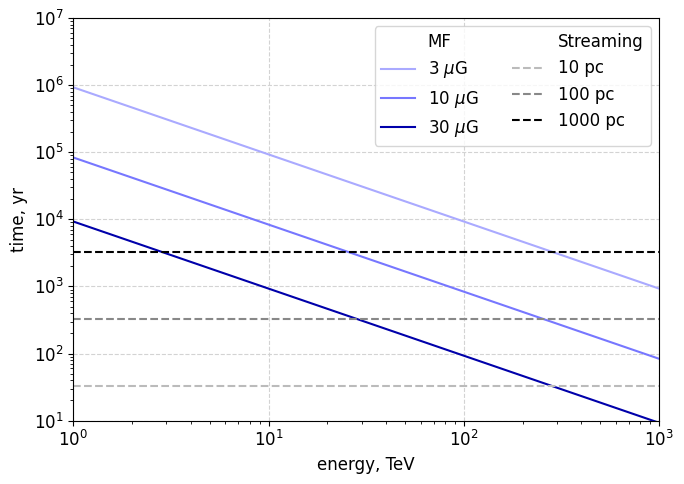

In [6]:
plt.figure(figsize=(7, 5))
set_plotting_defaults()

colors = ['#aaf', '#77f', '#00a']
plt.plot(1, 1, label='MF', linewidth=0)
for i, b in enumerate(B):
    plt.loglog(E.to(u.TeV), synchrotron_cooling_time(b, E).to(u.yr), label=f"{b/uGauss:.0f} "r"$\mu$G", color=colors[i])

colors = ['#bbb', '#888', '#000']
plt.plot(1, 1, label='Streaming', linewidth=0)
for i, d in enumerate(D):
    t_d = (d / cst.c).to(u.yr)
    plt.loglog(E.to(u.TeV), t_d * np.ones_like(E.value), color=colors[i], label=f"{d/u.pc:.0f} pc", linestyle='--')

plt.grid(True, linestyle='--')

plt.xlabel("energy, TeV")
plt.xlim(1, 1e3)

plt.ylabel("time, yr")
plt.ylim(10, 1e7)

plt.legend(loc=1, ncol=2)
plt.tight_layout()
save_figure("timescales")
plt.show()